In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
from collections import defaultdict
import json
from torchvision.models.detection.retinanet import RetinaNet
from torchvision.models import *
import tensorflow_hub as hub
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.io.image import *
from torchvision.models.detection import retinanet_resnet50_fpn_v2, RetinaNet_ResNet50_FPN_V2_Weights
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image
plt.rcParams['figure.figsize'] = (15,15)

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [ ]:
from ultralytics import YOLO
import torch


model = YOLO('yolov8n.pt')

In [ ]:
!mkdir -p coco/annotations

In [ ]:
%cd coco/
!pwd


/content/coco
/content/coco


In [ ]:
!wget http://images.cocodataset.org/zips/val2017.zip
!unzip val2017.zip && rm val2017.zip


Streaming output truncated to the last 5000 lines.
 extracting: val2017/000000212226.jpg  
 extracting: val2017/000000231527.jpg  
 extracting: val2017/000000578922.jpg  
 extracting: val2017/000000062808.jpg  
 extracting: val2017/000000119038.jpg  
 extracting: val2017/000000114871.jpg  
 extracting: val2017/000000463918.jpg  
 extracting: val2017/000000365745.jpg  
 extracting: val2017/000000320425.jpg  
 extracting: val2017/000000481404.jpg  
 extracting: val2017/000000314294.jpg  
 extracting: val2017/000000335328.jpg  
 extracting: val2017/000000513688.jpg  
 extracting: val2017/000000158548.jpg  
 extracting: val2017/000000132116.jpg  
 extracting: val2017/000000415238.jpg  
 extracting: val2017/000000321333.jpg  
 extracting: val2017/000000081738.jpg  
 extracting: val2017/000000577584.jpg  
 extracting: val2017/000000346905.jpg  
 extracting: val2017/000000433980.jpg  
 extracting: val2017/000000228144.jpg  
 extracting: val2017/000000041872.jpg  
 extracting: val2017/00000011

In [ ]:
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip annotations_trainval2017.zip -d annotations && rm annotations_trainval2017.zip


--2025-06-25 13:30:02--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.182.32.137, 52.217.231.169, 3.5.29.163, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.182.32.137|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_trainva 100%[===================>] 241.19M  59.5MB/s    in 4.5s    

2025-06-25 13:30:06 (53.4 MB/s) - ‘annotations_trainval2017.zip’ saved [252907541/252907541]

Archive:  annotations_trainval2017.zip
  inflating: annotations/annotations/instances_train2017.json  
  inflating: annotations/annotations/instances_val2017.json  
  inflating: annotations/annotations/captions_train2017.json  
  inflating: annotations/annotations/captions_val2017.json  
  inflating: annotations/annotations/person_keypoints_train2017.json  
  inflating: annotations/annotatio

In [ ]:
def draw_boxes(image, boxes, labels, category_ids_names):
    fig, ax = plt.subplots()
    for (i,bbox) in enumerate(boxes):
        name = category_ids_names[int(labels[i])]


        x = float(bbox[0])
        y = float(bbox[1])
        w = float(bbox[2])
        h = float(bbox[3])


        plt.text(x+1, y-5, name,fontdict={'fontsize':18.0, 'fontweight':'medium','color': 'white', 'backgroundcolor':'red'})
        bb = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(bb)
        #print("ana hena")

    ax.axis('off')
    ax.imshow(image.permute(1, 2, 0).cpu().numpy())
    plt.show()


In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from torchvision.datasets import CocoDetection
from tqdm import tqdm

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
# coco_idx_to_cat_id = {i: cat_id for i, cat_id in enumerate(coco_gt.getCatIds())}

In [ ]:
annotation_val="/content/coco/annotations/annotations/instances_val2017.json"
imgs_path="/content/coco/val2017"
coco_gt=COCO(annotation_file=annotation_val)
coco_idx_to_cat_id = {i: cat_id for i, cat_id in enumerate(coco_gt.getCatIds())}
dataset = CocoDetection(root=imgs_path, annFile=annotation_val)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))
results=[]

for idx, (images, targets) in enumerate(dataloader):
    image = images[0]
    target = targets[0]

    if len(target) == 0:
        continue

    image_id = target[0]["image_id"]

    # Run inference (YOLO supports PIL, numpy, or path; here we use numpy)
    image_np = image.convert("RGB")  # PIL image
    yolo_out = model(image_np)[0]  # YOLO returns a list, take first result

    boxes = yolo_out.boxes.xyxy.cpu().numpy()
    scores = yolo_out.boxes.conf.cpu().numpy()
    labels = yolo_out.boxes.cls.cpu().numpy().astype(int)

    for box, score, label in zip(boxes, scores, labels):
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min

        results.append({
            "image_id": int(image_id),
            "category_id": int(coco_idx_to_cat_id[label]),
            "bbox": [float(x_min), float(y_min), float(width), float(height)],
            "score": float(score)
        })

    if idx % 100 == 0:
        print(f"Processed {idx} images")


Streaming output truncated to the last 5000 lines.
Speed: 1.8ms preprocess, 13.6ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

0: 448x640 1 airplane, 9.8ms
Speed: 5.6ms preprocess, 9.8ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)

0: 480x640 2 giraffes, 9.4ms
Speed: 1.8ms preprocess, 9.4ms inference, 7.3ms postprocess per image at shape (1, 3, 480, 640)

0: 608x640 2 persons, 17.0ms
Speed: 2.1ms preprocess, 17.0ms inference, 1.8ms postprocess per image at shape (1, 3, 608, 640)

0: 448x640 9 persons, 1 backpack, 1 handbag, 5 ties, 1 laptop, 2 remotes, 1 keyboard, 19.7ms
Speed: 1.7ms preprocess, 19.7ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)

0: 480x640 11 elephants, 15.1ms
Speed: 1.9ms preprocess, 15.1ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

0: 416x640 1 person, 1 wine glass, 1 chair, 1 cell phone, 14.2ms
Speed: 1.6ms preprocess, 14.2ms inference, 1.6ms postprocess per image at shape (1, 3,

In [ ]:
import json

with open("yolo_coco_results.json", "w") as f:
    json.dump(results, f)


In [ ]:
from pycocotools.cocoeval import COCOeval

coco_dt = coco_gt.loadRes("yolo_coco_results.json")
coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()


Loading and preparing results...
DONE (t=0.10s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=13.07s).
Accumulating evaluation results...
DONE (t=1.75s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.313
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.423
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.345
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.113
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.343
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.480
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.260
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.362
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.366
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

In [ ]:
map_50_95 = coco_eval.stats[0]   # mAP @[ IoU=0.50:0.95 ]
map_50 = coco_eval.stats[1]      # mAP @[ IoU=0.50 ]
map_75 = coco_eval.stats[2]      # mAP @[ IoU=0.75 ]

print(f"mAP@[.50:.95]: {map_50_95:.4f}")
print(f"mAP@0.50: {map_50:.4f}")
print(f"mAP@0.75: {map_75:.4f}")


mAP@[.50:.95]: 0.3133
mAP@0.50: 0.4226
mAP@0.75: 0.3452


In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO

def show_random_yolo_prediction(dataset, model, class_names, device='cpu', score_thresh=0.3):
    idx = random.randint(0, len(dataset) - 1)
    img, target = dataset[idx]

    # Get image ID and filename
    image_id = target[0]["image_id"]
    file_name = dataset.coco.loadImgs(image_id)[0]["file_name"]
    img_path = f"{dataset.root}/{file_name}"

    # Load image using PIL
    pil_img = Image.open(img_path).convert("RGB")

    # Run YOLO inference
    results = model(pil_img)[0]  # YOLO returns a list; take first result

    boxes = results.boxes.xyxy.cpu().numpy()
    scores = results.boxes.conf.cpu().numpy()
    labels = results.boxes.cls.cpu().numpy().astype(int)

    # Filter boxes by score threshold
    keep = scores >= score_thresh
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]

    # Plot the image
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(pil_img)

    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        class_name = class_names[label] if label < len(class_names) else f"ID {label}"
        ax.text(x1, y1 - 5, f"{class_name} ({score:.2f})", color='lime', fontsize=12)

    ax.set_title(f"Random YOLO Prediction (Image ID {image_id})")
    plt.axis('off')
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

def visualize_prediction(image, pred, threshold=0.5):
    img = image.permute(1, 2, 0).cpu().numpy()
    img = (img * 255).astype(np.uint8)
    draw = ImageDraw.Draw(Image.fromarray(img))

    for i, score in enumerate(pred['scores']):
        if score < threshold:
            continue
        box = pred['boxes'][i].cpu().numpy()
        label = pred['labels'][i].item()
        draw.rectangle(box.tolist(), outline="red", width=2)
        draw.text((box[0], box[1]), f"{label}:{score:.2f}", fill="red")

    plt.imshow(img)
    plt.axis('off')
    plt.show()


In [ ]:
from torchvision.datasets import CocoDetection

In [ ]:
coco_val = CocoDetection(
    root="/content/coco/val2017",
    annFile=annotation_val
)

loading annotations into memory...
Done (t=1.35s)
creating index...
index created!



0: 448x640 17 persons, 1 tennis racket, 3 chairs, 11.3ms
Speed: 1.8ms preprocess, 11.3ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)


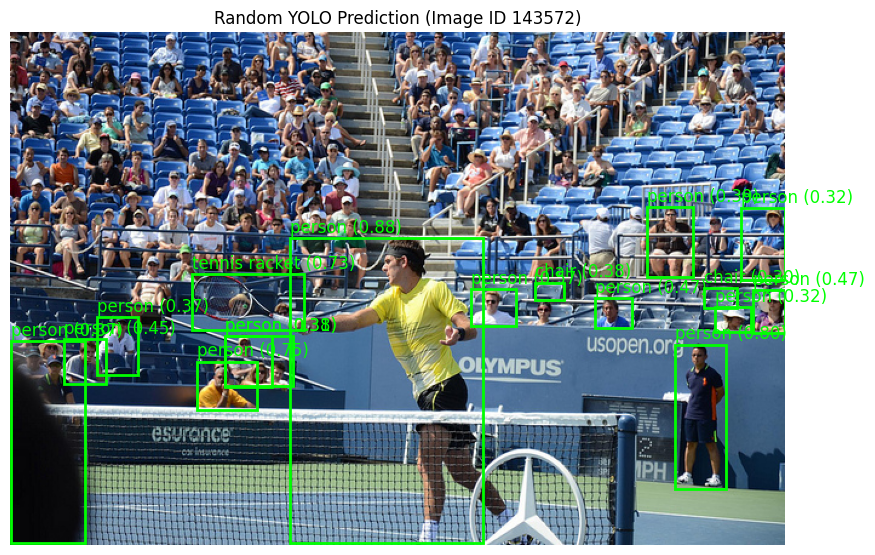

In [ ]:
COCO_CLASSES = model.names  # or list from COCO documentation

# Show random prediction
show_random_yolo_prediction(coco_val, model, COCO_CLASSES)


0: 480x640 1 person, 1 baseball glove, 18.9ms
Speed: 2.2ms preprocess, 18.9ms inference, 5.7ms postprocess per image at shape (1, 3, 480, 640)


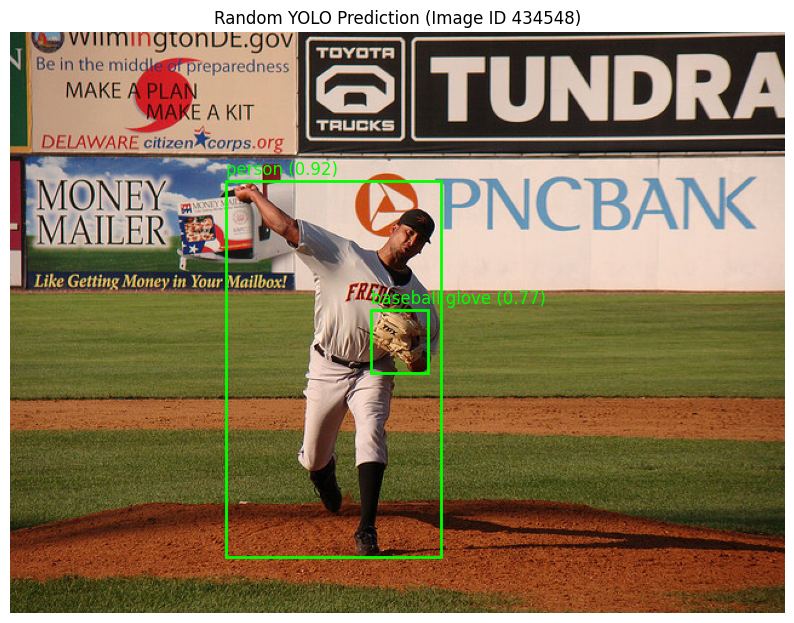

In [ ]:
show_random_yolo_prediction(coco_val, model, COCO_CLASSES)


0: 640x480 3 chairs, 1 dining table, 1 refrigerator, 17.9ms
Speed: 4.8ms preprocess, 17.9ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 480)


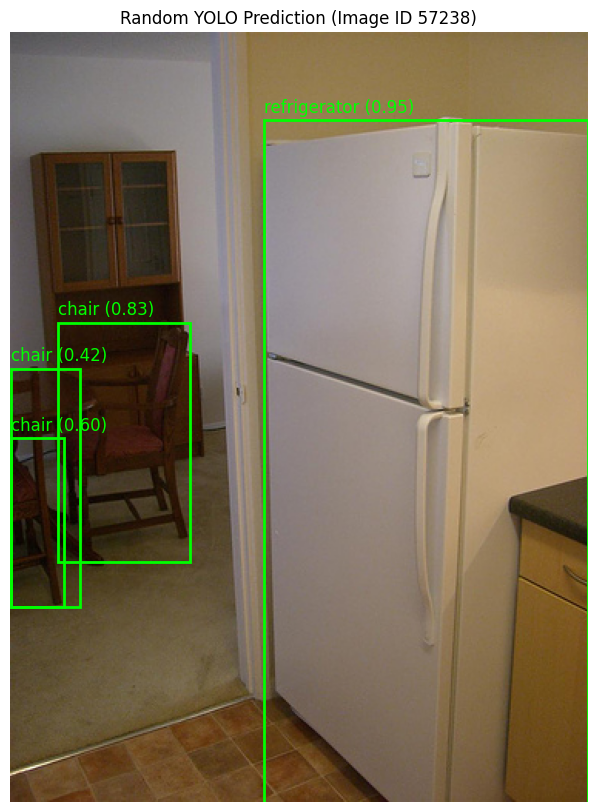

In [ ]:
show_random_yolo_prediction(coco_val, model, COCO_CLASSES)


0: 640x480 1 person, 3 cups, 1 bowl, 1 cake, 1 chair, 7.5ms
Speed: 2.5ms preprocess, 7.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)


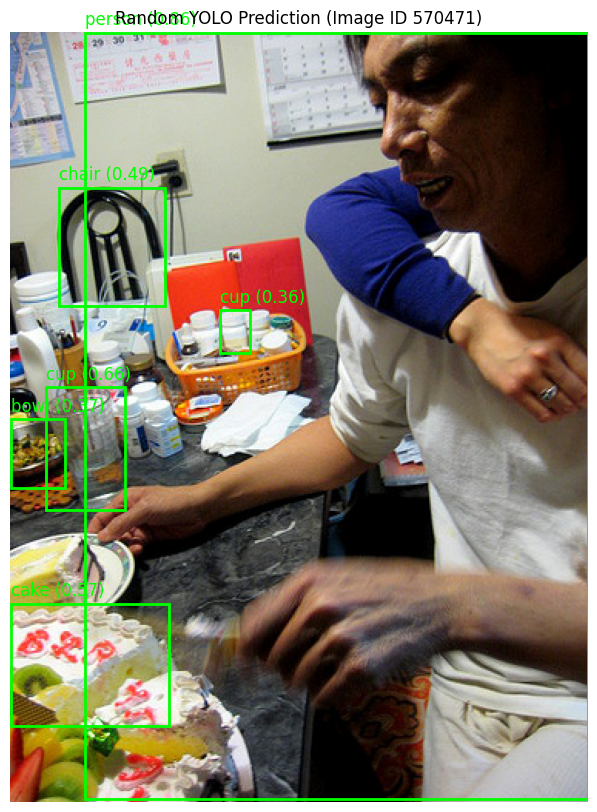

In [ ]:
show_random_yolo_prediction(coco_val, model, COCO_CLASSES)